 # Performance Comparison: Scalar vs Vectorized Implementations



 This notebook benchmarks the performance of the vectorized geopack functions:



 - Coordinate transformations (GSM/GSE, GEO/MAG, etc.)

 - Field-vector conversions (bspcar, bcarsp)

 - Tsyganenko external field models (T89/T96/T01/T04)

 - Internal field models (Dipole, IGRF)

 - (Optional) Field line tracing (only if a vectorized tracer exists in your geopack namespace)



 Notes

 -----

 - This notebook is about **performance** (timing/speed), not numerical accuracy.

 - Some models (notably **T01/T04**) have a recommended validity domain (sunward of x = -15 Re).

   We therefore **sample model points per-model** to avoid warnings and out-of-domain calls in benchmarks.

 - Times depend strongly on CPU, BLAS/NumPy build, and Python version. Treat results as indicative.

In [1]:
# Imports / environment
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopack
import time
import os
import gc
from datetime import datetime

# psutil is optional (used only for memory reporting)
try:
    import psutil
    _HAS_PSUTIL = True
except Exception:
    psutil = None
    _HAS_PSUTIL = False

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

# Initialize geopack
ut = datetime(2020, 1, 1, 12, 0, 0).timestamp()
ps = geopack.recalc(ut)

print("Environment")
print("=" * 60)
print("datetime(UT):", datetime.fromtimestamp(ut))
print("ps (tilt):", ps)
if _HAS_PSUTIL:
    vm = psutil.virtual_memory()
    print(f"CPU cores: {psutil.cpu_count(logical=True)}  RAM: {vm.total/1e9:.1f} GB")
else:
    print("psutil: not available (memory section will be limited)")
print("numpy:", np.__version__)


Load IGRF coefficients ...
Environment
datetime(UT): 2020-01-01 12:00:00
ps (tilt): -0.5451500462386779
CPU cores: 8  RAM: 8.2 GB
numpy: 2.2.6


 ## 1. Setup and Methodology <a name="setup"></a>



 We measure:

 - **Execution time** for different array sizes

 - **Speedup factor** = scalar_time / vector_time

 - **Processing rate** (points/second)



 Benchmark policy:

 - Use `time.perf_counter()` (high-resolution timer)

 - Use a small warmup call for vector functions

 - For large n, scalar timing is capped at `max_scalar_points` and extrapolated

   (reported as "extrapolated" in the result dict)

In [2]:
# Test sizes (kept moderate for interactive execution)
test_sizes = [1, 10, 50, 100, 500, 1000, 5000, 10000]

# Scalar cap for timing (extrapolate above this)
MAX_SCALAR_POINTS = 1000

# Repeats (take min)
N_REPEATS = 3

# RNG seed
SEED = 42

def _now():
    return time.perf_counter()

def _as_f64(a):
    return np.asarray(a, dtype=np.float64)

def sample_xyz(n_points, xlim, ylim, zlim, seed=SEED):
    """Sample Cartesian points with float64 dtype."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(xlim[0], xlim[1], n_points)
    y = rng.uniform(ylim[0], ylim[1], n_points)
    z = rng.uniform(zlim[0], zlim[1], n_points)
    return _as_f64(x), _as_f64(y), _as_f64(z)

def sample_spherical_inputs(n_points, seed=SEED):
    """Sample (theta, phi, br, bt, bp) for bspcar-style calls."""
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0.0, np.pi, n_points)
    phi   = rng.uniform(0.0, 2*np.pi, n_points)
    br = rng.normal(0.0, 1.0, n_points)
    bt = rng.normal(0.0, 1.0, n_points)
    bp = rng.normal(0.0, 1.0, n_points)
    return (_as_f64(theta), _as_f64(phi), _as_f64(br), _as_f64(bt), _as_f64(bp))

def measure_performance(
    scalar_func,
    vector_func,
    n_points,
    func_type,
    *,
    params=None,
    model_name=None,
    direction=1,
    n_repeats=N_REPEATS,
    max_scalar_points=MAX_SCALAR_POINTS,
    seed=SEED,
):
    """
    Measure scalar vs vector performance.

    func_type:
      - "coord" : signature (x,y,z,dir)
      - "sphcar": signature (x,y,z,dir) but expects cart->sph for dir=-1 (recommended here)
      - "bspcar": signature (theta,phi,br,bt,bp)
      - "bcarsp": signature (x,y,z,bx,by,bz)
      - "model" : signature (params, ps, x,y,z)  (T89 uses int iopt as params)
      - "igrf"  : signature (x,y,z)  (no ps)
      - "dip"   : signature (x,y,z)  (no ps)
    """
    # Per-type input generation
    if func_type in ("coord", "sphcar"):
        # Cartesian-like inputs for transforms; sphcar is safest in car->sph mode (dir=-1)
        x, y, z = sample_xyz(n_points, (-15, 15), (-15, 15), (-15, 15), seed=seed)
    elif func_type == "model":
        # Model-domain-aware sampling:
        # - T01/T04: avoid x < -15 (recommended validity)
        # - Others: allow wider tail sampling
        if model_name is not None and model_name.upper() in ("T01", "T04"):
            x, y, z = sample_xyz(n_points, (-15.0, 12.0), (-15, 15), (-15, 15), seed=seed)
        else:
            x, y, z = sample_xyz(n_points, (-25.0, 12.0), (-15, 15), (-15, 15), seed=seed)
    elif func_type in ("igrf", "dip"):
        # Keep IGRF stable: near-Earth domain (typical usage)
        x, y, z = sample_xyz(n_points, (-10.0, 10.0), (-10.0, 10.0), (-10.0, 10.0), seed=seed)
    elif func_type == "bspcar":
        theta, phi, br, bt, bp = sample_spherical_inputs(n_points, seed=seed)
    elif func_type == "bcarsp":
        x, y, z = sample_xyz(n_points, (-15, 15), (-15, 15), (-15, 15), seed=seed)
        bx = 0.1 * x
        by = 0.1 * y
        bz = 0.1 * z
    else:
        raise ValueError(f"Unknown func_type: {func_type}")

    # Warmup (vector only)
    try:
        if func_type == "coord":
            vector_func(x[:5], y[:5], z[:5], direction)
        elif func_type == "sphcar":
            vector_func(x[:5], y[:5], z[:5], direction)
        elif func_type == "model":
            vector_func(params, ps, x[:5], y[:5], z[:5])
        elif func_type in ("igrf", "dip"):
            vector_func(x[:5], y[:5], z[:5])
        elif func_type == "bspcar":
            vector_func(theta[:5], phi[:5], br[:5], bt[:5], bp[:5])
        elif func_type == "bcarsp":
            vector_func(x[:5], y[:5], z[:5], bx[:5], by[:5], bz[:5])
    except Exception:
        # Warmup is best-effort; ignore if function doesn't like short inputs in some envs
        pass

    # Scalar timing (cap and extrapolate)
    n_scalar = min(n_points, max_scalar_points)
    scalar_times = []
    for _ in range(n_repeats):
        t0 = _now()
        if func_type == "coord":
            for i in range(n_scalar):
                scalar_func(float(x[i]), float(y[i]), float(z[i]), int(direction))
        elif func_type == "sphcar":
            for i in range(n_scalar):
                scalar_func(float(x[i]), float(y[i]), float(z[i]), int(direction))
        elif func_type == "model":
            for i in range(n_scalar):
                scalar_func(params, ps, float(x[i]), float(y[i]), float(z[i]))
        elif func_type in ("igrf", "dip"):
            for i in range(n_scalar):
                scalar_func(float(x[i]), float(y[i]), float(z[i]))
        elif func_type == "bspcar":
            for i in range(n_scalar):
                scalar_func(float(theta[i]), float(phi[i]), float(br[i]), float(bt[i]), float(bp[i]))
        elif func_type == "bcarsp":
            for i in range(n_scalar):
                scalar_func(float(x[i]), float(y[i]), float(z[i]), float(bx[i]), float(by[i]), float(bz[i]))
        scalar_times.append(_now() - t0)

    scalar_time_meas = float(np.min(scalar_times))
    extrapolated = n_scalar < n_points
    scalar_time = scalar_time_meas * (n_points / max(n_scalar, 1)) if extrapolated else scalar_time_meas

    # Vector timing (full n_points)
    vector_times = []
    for _ in range(n_repeats):
        t0 = _now()
        if func_type == "coord":
            vector_func(x, y, z, direction)
        elif func_type == "sphcar":
            vector_func(x, y, z, direction)
        elif func_type == "model":
            vector_func(params, ps, x, y, z)
        elif func_type in ("igrf", "dip"):
            vector_func(x, y, z)
        elif func_type == "bspcar":
            vector_func(theta, phi, br, bt, bp)
        elif func_type == "bcarsp":
            vector_func(x, y, z, bx, by, bz)
        vector_times.append(_now() - t0)

    vector_time = float(np.min(vector_times))

    # Metrics
    speedup = scalar_time / max(vector_time, 1e-15)
    scalar_rate = n_points / max(scalar_time, 1e-15)
    vector_rate = n_points / max(vector_time, 1e-15)

    return {
        "n_points": int(n_points),
        "scalar_time_s": float(scalar_time),
        "vector_time_s": float(vector_time),
        "speedup_x": float(speedup),
        "scalar_rate_pts_s": float(scalar_rate),
        "vector_rate_pts_s": float(vector_rate),
        "scalar_extrapolated": bool(extrapolated),
        "n_scalar_measured": int(n_scalar),
    }

print("Benchmark setup complete.")
print(f"test_sizes: {test_sizes}")
print(f"MAX_SCALAR_POINTS: {MAX_SCALAR_POINTS}, N_REPEATS: {N_REPEATS}")


Benchmark setup complete.
test_sizes: [1, 10, 50, 100, 500, 1000, 5000, 10000]
MAX_SCALAR_POINTS: 1000, N_REPEATS: 3


 ## 2. Coordinate Transformation Performance <a name="coordinates"></a>

In [3]:
# Coordinate functions to benchmark
# For sphcar we benchmark the common "car -> sph" direction (dir = -1)
coord_functions = [
    ("gsmgse", geopack.gsmgse, geopack.gsmgse_vectorized, "GSM ↔ GSE", 1, "coord"),
    ("geigeo", geopack.geigeo, geopack.geigeo_vectorized, "GEI ↔ GEO", 1, "coord"),
    ("magsm",  geopack.magsm,  geopack.magsm_vectorized,  "MAG ↔ SM",  1, "coord"),
    ("smgsm",  geopack.smgsm,  geopack.smgsm_vectorized,  "SM ↔ GSM",  1, "coord"),
    ("geomag", geopack.geomag, geopack.geomag_vectorized, "GEO ↔ MAG", 1, "coord"),
    ("geogsm", geopack.geogsm, geopack.geogsm_vectorized, "GEO ↔ GSM", 1, "coord"),
    ("gswgsm", geopack.gswgsm, geopack.gswgsm_vectorized, "GSW ↔ GSM", 1, "coord"),
    ("sphcar", geopack.sphcar, geopack.sphcar_vectorized, "Cartesian ↔ Spherical", -1, "sphcar"),
    # field-vector conversions (not a coordinate transform, but grouped here)
    ("bspcar", geopack.bspcar, geopack.bspcar_vectorized, "B(sph) → B(car)", None, "bspcar"),
    ("bcarsp", geopack.bcarsp, geopack.bcarsp_vectorized, "B(car) → B(sph)", None, "bcarsp"),
]

coord_results = {}
print("\nCoordinate / Field-Vector Function Performance")
print("=" * 90)
print(f"{'Function':10s} {'n':>8s} {'scalar(s)':>12s} {'vector(s)':>12s} {'speedup':>9s} {'rate(vec) pts/s':>16s}")

for func_name, f_s, f_v, desc, direction, ftype in coord_functions:
    rows = []
    for n in [100, 1000, 10000]:
        r = measure_performance(
            f_s, f_v, n,
            func_type=ftype,
            direction=(direction if direction is not None else 1),
        )
        rows.append(r)
        print(f"{func_name:10s} {n:8d} {r['scalar_time_s']:12.4f} {r['vector_time_s']:12.4f} "
              f"{r['speedup_x']:9.1f}x {r['vector_rate_pts_s']:16.0f}"
              + ("  (scalar extrap)" if r["scalar_extrapolated"] else ""))
    coord_results[func_name] = rows



Coordinate / Field-Vector Function Performance
Function          n    scalar(s)    vector(s)   speedup  rate(vec) pts/s
gsmgse          100       0.0002       0.0000      13.2x          7542047
gsmgse         1000       0.0011       0.0000      94.7x         88936322
gsmgse        10000       0.0105       0.0000     216.4x        206726893  (scalar extrap)
geigeo          100       0.0002       0.0000      12.9x          8395601
geigeo         1000       0.0010       0.0000      74.2x         73599764
geigeo        10000       0.0108       0.0001     144.9x        134093195  (scalar extrap)
magsm           100       0.0002       0.0000      11.7x          6565126
magsm          1000       0.0009       0.0000      73.9x         78659640
magsm         10000       0.0114       0.0001     194.2x        170925562  (scalar extrap)
smgsm           100       0.0001       0.0000       7.4x          6432937
smgsm          1000       0.0013       0.0000      67.6x         51931865
smgsm         

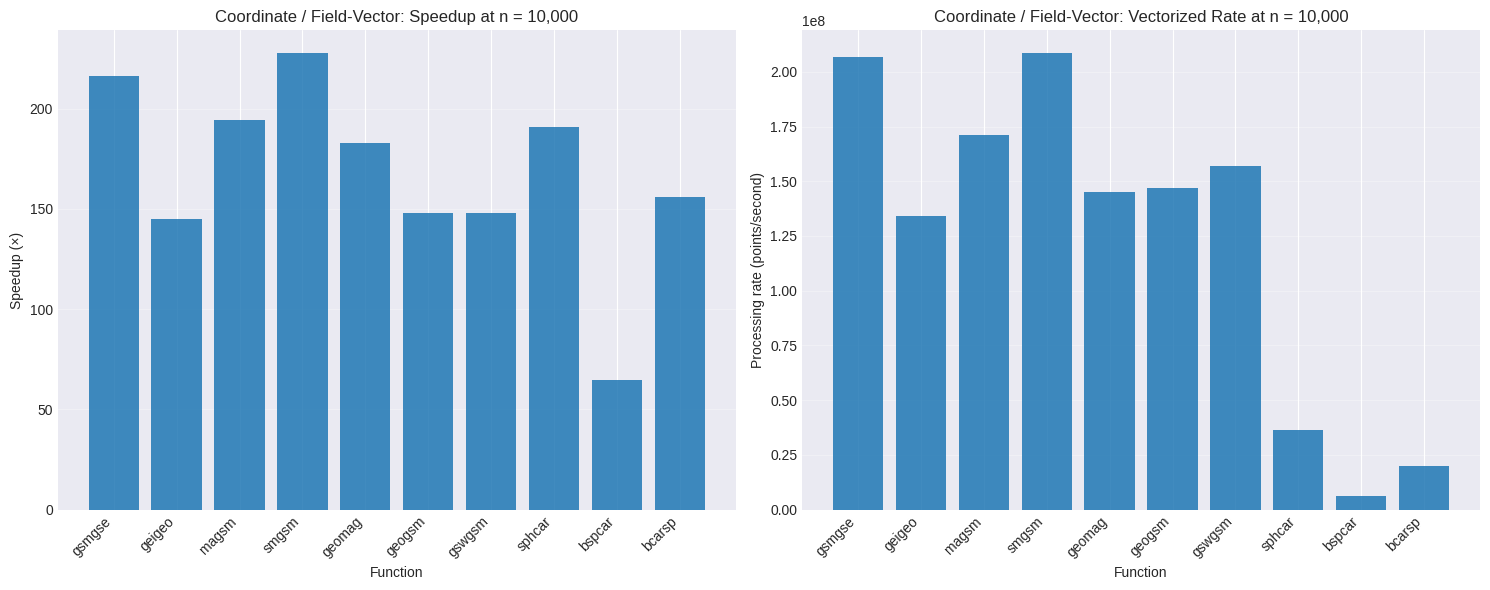

In [4]:
# Plot coordinate speedups and vector rates (n=10,000)
func_names = list(coord_results.keys())
speedups_10k = [coord_results[k][2]["speedup_x"] for k in func_names]
rates_10k = [coord_results[k][2]["vector_rate_pts_s"] for k in func_names]

xpos = np.arange(len(func_names))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.bar(xpos, speedups_10k, alpha=0.85)
ax1.set_xticks(xpos)
ax1.set_xticklabels(func_names, rotation=45, ha="right")
ax1.set_xlabel("Function")
ax1.set_ylabel("Speedup (×)")
ax1.set_title("Coordinate / Field-Vector: Speedup at n = 10,000")
ax1.grid(True, alpha=0.3, axis="y")

ax2.bar(xpos, rates_10k, alpha=0.85)
ax2.set_xticks(xpos)
ax2.set_xticklabels(func_names, rotation=45, ha="right")
ax2.set_xlabel("Function")
ax2.set_ylabel("Processing rate (points/second)")
ax2.set_title("Coordinate / Field-Vector: Vectorized Rate at n = 10,000")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


 ## 3. Magnetic Field Model Performance <a name="models"></a>



 We benchmark the **external** Tsyganenko models:

 - T89, T96, T01, T04



 Note:

 - For T01/T04 we sample **x ∈ [-15, 12] Re** to avoid out-of-domain warnings.

In [5]:
# Model parameters
parmod_default = np.zeros(10, dtype=np.float64)
parmod_default[0] = 3.0    # Pdyn (nPa)
parmod_default[1] = -20.0  # Dst (nT)
parmod_default[2] = 0.0    # ByIMF (nT)
parmod_default[3] = -5.0   # BzIMF (nT)

parmod_t01 = parmod_default.copy()
parmod_t01[4] = 2.0
parmod_t01[5] = 3.0

parmod_t04 = parmod_default.copy()
parmod_t04[4:10] = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]

model_functions = [
    ("T89", geopack.t89, geopack.t89_vectorized, 4),
    ("T96", geopack.t96, geopack.t96_vectorized, parmod_default),
    ("T01", geopack.t01, geopack.t01_vectorized, parmod_t01),
    ("T04", geopack.t04, geopack.t04_vectorized, parmod_t04),
]

model_results = {}
print("\nExternal Field Model Performance (Tsyganenko)")
print("=" * 90)
print(f"{'Model':6s} {'n':>8s} {'scalar(s)':>12s} {'vector(s)':>12s} {'speedup':>9s} {'rate(vec) pts/s':>16s}")

for model_name, f_s, f_v, params in model_functions:
    rows = []
    for n in [100, 1000, 10000]:
        r = measure_performance(
            f_s, f_v, n,
            func_type="model",
            params=params,
            model_name=model_name,
        )
        rows.append(r)
        print(f"{model_name:6s} {n:8d} {r['scalar_time_s']:12.4f} {r['vector_time_s']:12.4f} "
              f"{r['speedup_x']:9.1f}x {r['vector_rate_pts_s']:16.0f}"
              + ("  (scalar extrap)" if r["scalar_extrapolated"] else ""))
    model_results[model_name] = rows



External Field Model Performance (Tsyganenko)
Model         n    scalar(s)    vector(s)   speedup  rate(vec) pts/s
T89         100       0.0055       0.0003      16.2x           294557
T89        1000       0.0462       0.0005      85.0x          1840516
T89       10000       0.4763       0.0064      74.3x          1560041  (scalar extrap)
T96         100       0.1085       0.0233       4.7x             4293
T96        1000       1.0851       0.0360      30.1x            27743
T96       10000      10.7663       0.1172      91.8x            85305  (scalar extrap)
T01         100       0.1800       0.0205       8.8x             4885
T01        1000       1.8879       0.0430      44.0x            23283
T01       10000      18.4215       0.2901      63.5x            34472  (scalar extrap)
T04         100       0.2100       0.0198      10.6x             5063
T04        1000       2.2236       0.0445      50.0x            22492
T04       10000      19.5640       0.3289      59.5x           

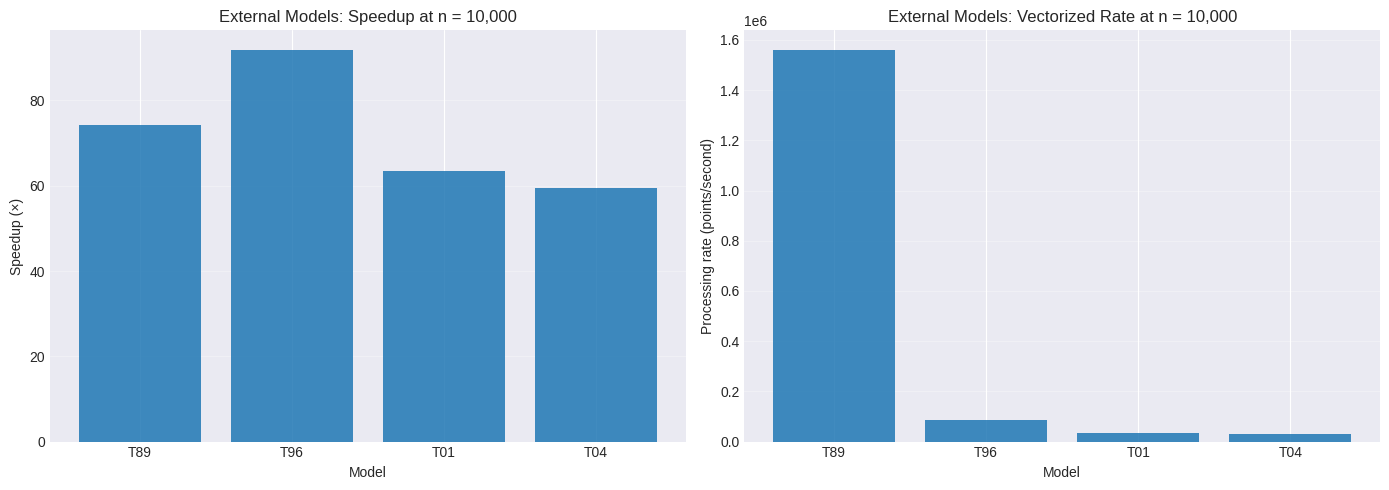

In [13]:
# Plot external model speedups and rates (n=10,000)
model_names = list(model_results.keys())
speedups_10k = [model_results[m][2]["speedup_x"] for m in model_names]
rates_10k = [model_results[m][2]["vector_rate_pts_s"] for m in model_names]

xpos = np.arange(len(model_names))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(xpos, speedups_10k, alpha=0.85)
ax1.set_xticks(xpos)
ax1.set_xticklabels(model_names)
ax1.set_xlabel("Model")
ax1.set_ylabel("Speedup (×)")
ax1.set_title("External Models: Speedup at n = 10,000")
ax1.grid(True, alpha=0.3, axis="y")

ax2.bar(xpos, rates_10k, alpha=0.85)
ax2.set_xticks(xpos)
ax2.set_xticklabels(model_names)
ax2.set_xlabel("Model")
ax2.set_ylabel("Processing rate (points/second)")
ax2.set_title("External Models: Vectorized Rate at n = 10,000")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


 ## 3b. Internal Field Performance (IGRF only)



 Dipole (`dip`) is already vectorization-native in geopack (it accepts arrays directly),

 so comparing "scalar vs vector" is not meaningful here.



 Instead, we benchmark only IGRF:

 - `igrf_gsw` vs `igrf_gsw_vectorized` (preferred if available)

 - `igrf_gsm` vs `igrf_gsm_vectorized` (fallback / optional)



 Notes:

 - IGRF is most meaningful near Earth; we sample within roughly ±10 Re.


Internal Field Performance (IGRF only)
Internal          n    scalar(s)    vector(s)   speedup  rate(vec) pts/s
IGRF_GSW        100       0.0065       0.0017       3.9x            59449
IGRF_GSW       1000       0.0928       0.0223       4.2x            44759
IGRF_GSW      10000       0.6747       0.0420      16.1x           238344  (scalar extrap)
IGRF_GSM        100       0.0057       0.0016       3.5x            61260
IGRF_GSM       1000       0.0579       0.0072       8.1x           139275
IGRF_GSM      10000       0.6053       0.0421      14.4x           237473  (scalar extrap)


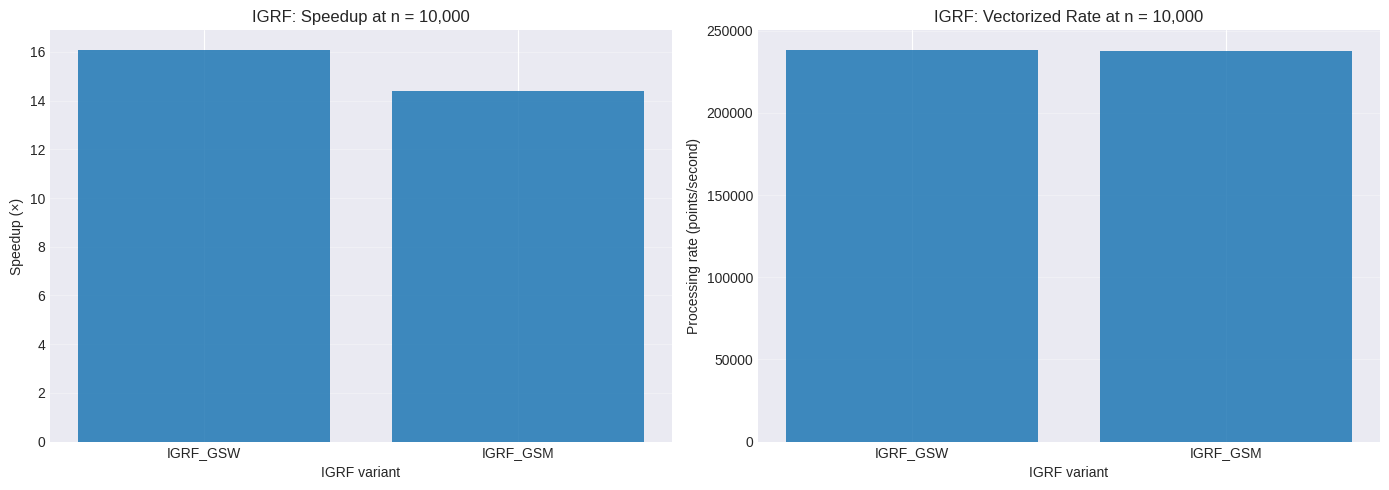

In [7]:
internal_results = {}

print("\nInternal Field Performance (IGRF only)")
print("=" * 90)
print(f"{'Internal':10s} {'n':>8s} {'scalar(s)':>12s} {'vector(s)':>12s} {'speedup':>9s} {'rate(vec) pts/s':>16s}")

# IGRF (GSW)
if hasattr(geopack, "igrf_gsw") and hasattr(geopack, "igrf_gsw_vectorized"):
    internal_results["IGRF_GSW"] = []
    for n in [100, 1000, 10000]:
        r = measure_performance(geopack.igrf_gsw, geopack.igrf_gsw_vectorized, n, func_type="igrf")
        internal_results["IGRF_GSW"].append(r)
        print(f"{'IGRF_GSW':10s} {n:8d} {r['scalar_time_s']:12.4f} {r['vector_time_s']:12.4f} "
              f"{r['speedup_x']:9.1f}x {r['vector_rate_pts_s']:16.0f}"
              + ("  (scalar extrap)" if r["scalar_extrapolated"] else ""))
else:
    print("IGRF_GSW benchmark skipped: geopack.igrf_gsw / igrf_gsw_vectorized not found")

# IGRF (GSM) - optional
if hasattr(geopack, "igrf_gsm") and hasattr(geopack, "igrf_gsm_vectorized"):
    internal_results["IGRF_GSM"] = []
    for n in [100, 1000, 10000]:
        r = measure_performance(geopack.igrf_gsm, geopack.igrf_gsm_vectorized, n, func_type="igrf")
        internal_results["IGRF_GSM"].append(r)
        print(f"{'IGRF_GSM':10s} {n:8d} {r['scalar_time_s']:12.4f} {r['vector_time_s']:12.4f} "
              f"{r['speedup_x']:9.1f}x {r['vector_rate_pts_s']:16.0f}"
              + ("  (scalar extrap)" if r["scalar_extrapolated"] else ""))
else:
    print("IGRF_GSM benchmark skipped: geopack.igrf_gsm / igrf_gsm_vectorized not found")

# Plot internal model speedups (n=10,000) if present
labels, speedups, rates = [], [], []
for k, rows in internal_results.items():
    if len(rows) >= 3:
        labels.append(k)
        speedups.append(rows[2]["speedup_x"])
        rates.append(rows[2]["vector_rate_pts_s"])

if labels:
    xpos = np.arange(len(labels))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.bar(xpos, speedups, alpha=0.85)
    ax1.set_xticks(xpos)
    ax1.set_xticklabels(labels)
    ax1.set_xlabel("IGRF variant")
    ax1.set_ylabel("Speedup (×)")
    ax1.set_title("IGRF: Speedup at n = 10,000")
    ax1.grid(True, alpha=0.3, axis="y")

    ax2.bar(xpos, rates, alpha=0.85)
    ax2.set_xticks(xpos)
    ax2.set_xticklabels(labels)
    ax2.set_xlabel("IGRF variant")
    ax2.set_ylabel("Processing rate (points/second)")
    ax2.set_title("IGRF: Vectorized Rate at n = 10,000")
    ax2.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()



 ## 4. Scaling Analysis <a name="scaling"></a>



 We run a more detailed scaling sweep for a representative coordinate transform and a representative model.

In [8]:
scaling_functions = [
    ("gsmgse", geopack.gsmgse, geopack.gsmgse_vectorized, "coord", dict(direction=1)),
    ("T96", geopack.t96, geopack.t96_vectorized, "model", dict(params=parmod_default, model_name="T96")),
]

scaling_results = {}
print("\nScaling analysis")
print("=" * 60)

for func_name, f_s, f_v, ftype, kwargs in scaling_functions:
    res = []
    print(f"\n{func_name}")
    for n in test_sizes:
        r = measure_performance(f_s, f_v, n, func_type=ftype, **kwargs)
        res.append(r)
        if n <= 10000:
            print(f"  n={n:6d}: speedup={r['speedup_x']:7.2f}x  vector={r['vector_time_s']:.4e}s")
    scaling_results[func_name] = res



Scaling analysis

gsmgse
  n=     1: speedup=   0.17x  vector=1.0918e-05s
  n=    10: speedup=   1.47x  vector=9.2170e-06s
  n=    50: speedup=   6.09x  vector=5.6150e-06s
  n=   100: speedup=  11.53x  vector=5.8270e-06s
  n=   500: speedup=  55.99x  vector=6.1120e-06s
  n=  1000: speedup=  37.86x  vector=1.8256e-05s
  n=  5000: speedup= 195.23x  vector=1.5621e-05s
  n= 10000: speedup= 171.82x  vector=4.1601e-05s

T96


  n=     1: speedup=   0.14x  vector=1.0185e-02s
  n=    10: speedup=   1.01x  vector=1.0225e-02s
  n=    50: speedup=   3.09x  vector=2.0343e-02s
  n=   100: speedup=   2.75x  vector=4.3701e-02s
  n=   500: speedup=  17.82x  vector=3.2321e-02s
  n=  1000: speedup=  31.99x  vector=3.5149e-02s
  n=  5000: speedup=  78.60x  vector=7.0129e-02s
  n= 10000: speedup= 100.71x  vector=1.1042e-01s


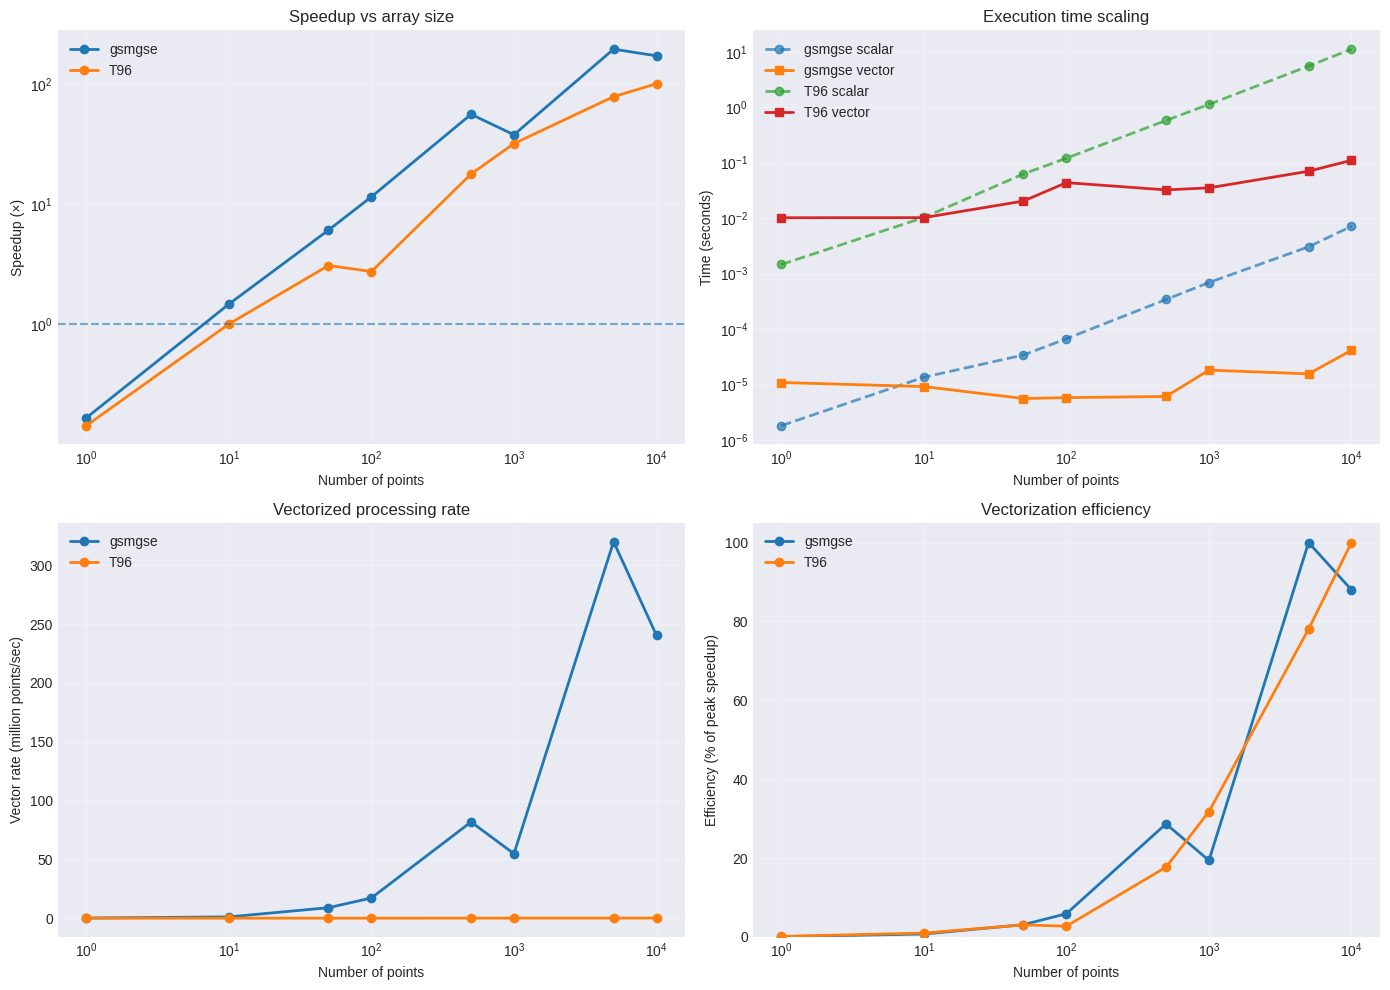

In [9]:
# Plot scaling curves
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Speedup vs size
for func_name, res in scaling_results.items():
    sizes = [r["n_points"] for r in res]
    speedups = [r["speedup_x"] for r in res]
    ax1.loglog(sizes, speedups, "o-", linewidth=2, label=func_name)
ax1.set_xlabel("Number of points")
ax1.set_ylabel("Speedup (×)")
ax1.set_title("Speedup vs array size")
ax1.grid(True, alpha=0.3)
ax1.axhline(1.0, linestyle="--", alpha=0.6)
ax1.legend()

# Time scaling
for func_name, res in scaling_results.items():
    sizes = [r["n_points"] for r in res]
    t_s = [r["scalar_time_s"] for r in res]
    t_v = [r["vector_time_s"] for r in res]
    ax2.loglog(sizes, t_s, "o--", linewidth=2, alpha=0.7, label=f"{func_name} scalar")
    ax2.loglog(sizes, t_v, "s-", linewidth=2, label=f"{func_name} vector")
ax2.set_xlabel("Number of points")
ax2.set_ylabel("Time (seconds)")
ax2.set_title("Execution time scaling")
ax2.grid(True, alpha=0.3)
ax2.legend()

# Vector rate
for func_name, res in scaling_results.items():
    sizes = [r["n_points"] for r in res]
    rates = [r["vector_rate_pts_s"] for r in res]
    ax3.semilogx(sizes, np.array(rates) / 1e6, "o-", linewidth=2, label=func_name)
ax3.set_xlabel("Number of points")
ax3.set_ylabel("Vector rate (million points/sec)")
ax3.set_title("Vectorized processing rate")
ax3.grid(True, alpha=0.3)
ax3.legend()

# Efficiency
for func_name, res in scaling_results.items():
    sizes = [r["n_points"] for r in res]
    speedups = np.array([r["speedup_x"] for r in res])
    eff = 100.0 * speedups / max(speedups.max(), 1e-15)
    ax4.semilogx(sizes, eff, "o-", linewidth=2, label=func_name)
ax4.set_xlabel("Number of points")
ax4.set_ylabel("Efficiency (% of peak speedup)")
ax4.set_title("Vectorization efficiency")
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 105)
ax4.legend()

plt.tight_layout()
plt.show()


 ## 5. Memory Efficiency <a name="memory"></a>



 This section provides a rough RSS-based memory estimate (best-effort).

 Memory numbers can be noisy; use for sanity-checking rather than exact accounting.

In [10]:
def measure_memory_usage_vector_call(call_fn, n_points, seed=SEED):
    """
    Measure memory (RSS) before and after one vectorized call.
    Requires psutil.
    """
    if not _HAS_PSUTIL:
        raise RuntimeError("psutil not available")

    process = psutil.Process(os.getpid())
    gc.collect()

    baseline = process.memory_info().rss / 1e6  # MB

    # Generate inputs (xyz only; call_fn closes over params as needed)
    x, y, z = sample_xyz(n_points, (-15, 15), (-15, 15), (-15, 15), seed=seed)
    after_data = process.memory_info().rss / 1e6  # MB

    _ = call_fn(x, y, z)
    after_call = process.memory_info().rss / 1e6  # MB

    # Cleanup
    del x, y, z, _
    gc.collect()
    after_cleanup = process.memory_info().rss / 1e6  # MB

    return {
        "baseline_MB": baseline,
        "inputs_MB": max(after_data - baseline, 0.0),
        "call_overhead_MB": max(after_call - after_data, 0.0),
        "total_peak_MB": max(after_call - baseline, 0.0),
        "post_cleanup_MB": after_cleanup,
    }

memory_sizes = [1000, 10000, 100000]  # keep moderate
memory_rows = []

if _HAS_PSUTIL:
    print("\nMemory usage (RSS, best-effort)")
    print("=" * 80)
    print(f"{'N':>10s} {'inputs(MB)':>12s} {'overhead(MB)':>14s} {'peak(MB)':>10s}")

    # Example: T96 vector call
    def _call_t96(x, y, z):
        return geopack.t96_vectorized(parmod_default, ps, x, y, z)

    for n in memory_sizes:
        try:
            mem = measure_memory_usage_vector_call(_call_t96, n)
            memory_rows.append({"component": "T96_vector", "n_points": n, **mem})
            print(f"{n:10d} {mem['inputs_MB']:12.1f} {mem['call_overhead_MB']:14.1f} {mem['total_peak_MB']:10.1f}")
        except MemoryError:
            print(f"{n:10d} MemoryError")
            break

    # Optional: IGRF memory
    if hasattr(geopack, "igrf_gsw_vectorized"):
        def _call_igrf(x, y, z):
            return geopack.igrf_gsw_vectorized(x, y, z)

        for n in memory_sizes:
            try:
                mem = measure_memory_usage_vector_call(_call_igrf, n, seed=SEED+1)
                memory_rows.append({"component": "IGRF_GSW_vector", "n_points": n, **mem})
            except Exception:
                break

    if memory_rows:
        df_mem = pd.DataFrame(memory_rows)
        display(df_mem)
else:
    print("\nMemory section skipped (psutil not available).")



Memory usage (RSS, best-effort)
         N   inputs(MB)   overhead(MB)   peak(MB)
      1000          0.0            0.0        0.0
     10000          0.0            0.1        0.1
    100000          0.0            9.2        9.2


,component,n_points,baseline_MB,inputs_MB,call_overhead_MB,total_peak_MB,post_cleanup_MB
0,T96_vector,1000,196.182016,0.0,0.000000,0.000000,196.182016
1,T96_vector,10000,196.182016,0.0,0.131072,0.131072,196.313088
2,T96_vector,100000,196.313088,0.0,9.211904,9.211904,205.524992
3,IGRF_GSW_vector,1000,205.524992,0.0,0.000000,0.000000,205.524992
4,IGRF_GSW_vector,10000,205.524992,0.0,0.000000,0.000000,205.524992
5,IGRF_GSW_vector,100000,205.524992,0.0,2.240512,2.240512,207.765504


 ## 6. Best Practices <a name="practices"></a>

In [11]:
recommendations = pd.DataFrame([
    {"Array Size": "1–10 points",    "Recommendation": "Scalar is fine",           "Reason": "Vector overhead often dominates"},
    {"Array Size": "10–100 points",  "Recommendation": "Depends",                  "Reason": "Vector can win if repeated many times"},
    {"Array Size": "100–1,000",      "Recommendation": "Prefer vectorized",        "Reason": "Clear speedup with low overhead"},
    {"Array Size": "1,000+",         "Recommendation": "Always vectorized",        "Reason": "Best throughput; use chunking if needed"},
    {"Array Size": "Very large (≥1e6)", "Recommendation": "Chunking recommended",  "Reason": "Avoid large temporary allocations / RAM pressure"},
])
print("\nPerformance Recommendations")
print("=" * 80)
print(recommendations.to_string(index=False))



Performance Recommendations
       Array Size       Recommendation                                           Reason
      1–10 points       Scalar is fine                  Vector overhead often dominates
    10–100 points              Depends            Vector can win if repeated many times
        100–1,000    Prefer vectorized                  Clear speedup with low overhead
           1,000+    Always vectorized          Best throughput; use chunking if needed
Very large (≥1e6) Chunking recommended Avoid large temporary allocations / RAM pressure


 ## 7. README-ready Performance Benchmarks (copy/paste cell)



 This cell produces a compact table designed to be pasted into README.

 It benchmarks **n=1000 points** for:

 - T89/T96/T01/T04 (external models)

 - IGRF (GSW if available; else GSM if available)

 - Coordinate transforms (aggregate of a few common transforms)

 - Field line tracing (only if a vectorized tracer exists; otherwise shown as N/A)

In [12]:
def _bench_exact_1000_scalar_vector(scalar_call, vector_call, n_points=1000, n_repeats=3):
    # scalar
    t_s = []
    for _ in range(n_repeats):
        t0 = _now()
        scalar_call(n_points)
        t_s.append(_now() - t0)
    t_scalar = float(np.min(t_s))

    # vector
    t_v = []
    for _ in range(n_repeats):
        t0 = _now()
        vector_call(n_points)
        t_v.append(_now() - t0)
    t_vec = float(np.min(t_v))

    sp = t_scalar / max(t_vec, 1e-15)
    return t_scalar, t_vec, sp

def _make_xyz_for_models(n_points, model_name, seed=SEED):
    if model_name.upper() in ("T01", "T04"):
        return sample_xyz(n_points, (-15.0, 12.0), (-15, 15), (-15, 15), seed=seed)
    return sample_xyz(n_points, (-25.0, 12.0), (-15, 15), (-15, 15), seed=seed)

N0 = 1000

# External models
bench_rows = []

for model_name, f_s, f_v, params in model_functions:
    x, y, z = _make_xyz_for_models(N0, model_name, seed=SEED)

    def _scalar_call(_n):
        for i in range(_n):
            f_s(params, ps, float(x[i]), float(y[i]), float(z[i]))

    def _vector_call(_n):
        f_v(params, ps, x[:_n], y[:_n], z[:_n])

    t_scalar, t_vec, sp = _bench_exact_1000_scalar_vector(_scalar_call, _vector_call, n_points=N0, n_repeats=3)
    bench_rows.append({"Component": f"{model_name} Model", "Scalar Time (1000 points) [s]": t_scalar,
                       "Vectorized Time [s]": t_vec, "Speedup": sp})

# IGRF (prefer GSW)
igrf_scalar = None
igrf_vector = None
igrf_label = None

if hasattr(geopack, "igrf_gsw") and hasattr(geopack, "igrf_gsw_vectorized"):
    igrf_scalar = geopack.igrf_gsw
    igrf_vector = geopack.igrf_gsw_vectorized
    igrf_label = "IGRF (GSW)"
elif hasattr(geopack, "igrf_gsm") and hasattr(geopack, "igrf_gsm_vectorized"):
    igrf_scalar = geopack.igrf_gsm
    igrf_vector = geopack.igrf_gsm_vectorized
    igrf_label = "IGRF (GSM)"

if igrf_scalar is not None:
    x, y, z = sample_xyz(N0, (-10.0, 10.0), (-10.0, 10.0), (-10.0, 10.0), seed=SEED+7)

    def _scalar_call(_n):
        for i in range(_n):
            igrf_scalar(float(x[i]), float(y[i]), float(z[i]))

    def _vector_call(_n):
        igrf_vector(x[:_n], y[:_n], z[:_n])

    t_scalar, t_vec, sp = _bench_exact_1000_scalar_vector(_scalar_call, _vector_call, n_points=N0, n_repeats=3)
    bench_rows.append({"Component": igrf_label, "Scalar Time (1000 points) [s]": t_scalar,
                       "Vectorized Time [s]": t_vec, "Speedup": sp})
else:
    bench_rows.append({"Component": "IGRF", "Scalar Time (1000 points) [s]": np.nan,
                       "Vectorized Time [s]": np.nan, "Speedup": np.nan})

# Coordinate transforms aggregate (pick a few common ones)
coord_subset = [
    ("gsmgse", geopack.gsmgse, geopack.gsmgse_vectorized, 1),
    ("geogsm", geopack.geogsm, geopack.geogsm_vectorized, 1),
    ("geomag", geopack.geomag, geopack.geomag_vectorized, 1),
    ("gswgsm", geopack.gswgsm, geopack.gswgsm_vectorized, 1),
]
x, y, z = sample_xyz(N0, (-15.0, 15.0), (-15.0, 15.0), (-15.0, 15.0), seed=SEED+11)

def _scalar_call(_n):
    for i in range(_n):
        for _, fs, _, d in coord_subset:
            fs(float(x[i]), float(y[i]), float(z[i]), int(d))

def _vector_call(_n):
    for _, _, fv, d in coord_subset:
        fv(x[:_n], y[:_n], z[:_n], int(d))

t_scalar, t_vec, sp = _bench_exact_1000_scalar_vector(_scalar_call, _vector_call, n_points=N0, n_repeats=3)
bench_rows.append({"Component": "Coordinate Transforms (subset)", "Scalar Time (1000 points) [s]": t_scalar,
                   "Vectorized Time [s]": t_vec, "Speedup": sp})

# Field line tracing (optional)
# We look for common vectorized tracer names. If none found, report N/A.
trace_scalar = getattr(geopack, "trace", None)
trace_vec = None
for cand in ["trace_vectorized", "tracev", "trace_line_vectorized", "trace_fieldline_vectorized"]:
    if hasattr(geopack, cand):
        trace_vec = getattr(geopack, cand)
        break

if trace_scalar is not None and trace_vec is not None:
    # Benchmark "1000 points" as "1000 start points, 1-step?" is ambiguous;
    # here we benchmark tracing 50 lines (kept moderate) and scale to 1000 as a rough proxy.
    # If you have a well-defined tracing workload, replace this with your official scenario.
    n_lines = 50
    xs, ys, zs = sample_xyz(n_lines, (-10, 10), (-5, 5), (-5, 5), seed=SEED+21)

    def _scalar_call(_n_ignored):
        for i in range(n_lines):
            trace_scalar(float(xs[i]), float(ys[i]), float(zs[i]), 1, rlim=10, r0=1, parmod=2, exname="t89", inname="igrf")

    def _vector_call(_n_ignored):
        trace_vec(xs, ys, zs, 1, rlim=10, r0=1, parmod=2, exname="t89", inname="igrf")

    t_scalar, t_vec, sp = _bench_exact_1000_scalar_vector(_scalar_call, _vector_call, n_points=1000, n_repeats=3)
    bench_rows.append({"Component": "Field Line Tracing", "Scalar Time (1000 points) [s]": t_scalar,
                       "Vectorized Time [s]": t_vec, "Speedup": sp})
else:
    bench_rows.append({"Component": "Field Line Tracing", "Scalar Time (1000 points) [s]": np.nan,
                       "Vectorized Time [s]": np.nan, "Speedup": np.nan})

df_bench = pd.DataFrame(bench_rows)

# Pretty display
display(df_bench)

# Markdown table string (README-ready)
def _fmt(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "N/A"
    if x >= 100:
        return f"**{x:.0f}x**"
    return f"**{x:.1f}x**"

md_lines = []
md_lines.append("## Performance Benchmarks\n")
md_lines.append("| Component | Scalar Time (1000 points) [s] | Vectorized Time [s] | Speedup |")
md_lines.append("|-----------|-------------------------------:|---------------------:|--------:|")
for _, row in df_bench.iterrows():
    comp = row["Component"]
    ts = row["Scalar Time (1000 points) [s]"]
    tv = row["Vectorized Time [s]"]
    sp = row["Speedup"]
    ts_s = "N/A" if (isinstance(ts, float) and np.isnan(ts)) else f"{ts:.3f}"
    tv_s = "N/A" if (isinstance(tv, float) and np.isnan(tv)) else f"{tv:.3f}"
    sp_s = "N/A" if (isinstance(sp, float) and np.isnan(sp)) else _fmt(sp)
    md_lines.append(f"| {comp} | {ts_s} | {tv_s} | {sp_s} |")

md_table = "\n".join(md_lines)
print("\n" + md_table)


,Component,Scalar Time (1000 points) [s],Vectorized Time [s],Speedup
0,T89 Model,0.061005,0.000508,120.097324
1,T96 Model,1.164081,0.036379,31.998892
2,T01 Model,1.952434,0.039179,49.834051
3,T04 Model,1.897907,0.042862,44.279065
4,IGRF (GSW),0.062630,0.006096,10.274218
5,Coordinate Transforms (subset),0.003651,0.000059,62.325799
6,Field Line Tracing,NaN,NaN,NaN



## Performance Benchmarks

| Component | Scalar Time (1000 points) [s] | Vectorized Time [s] | Speedup |
|-----------|-------------------------------:|---------------------:|--------:|
| T89 Model | 0.061 | 0.001 | **120x** |
| T96 Model | 1.164 | 0.036 | **32.0x** |
| T01 Model | 1.952 | 0.039 | **49.8x** |
| T04 Model | 1.898 | 0.043 | **44.3x** |
| IGRF (GSW) | 0.063 | 0.006 | **10.3x** |
| Coordinate Transforms (subset) | 0.004 | 0.000 | **62.3x** |
| Field Line Tracing | N/A | N/A | N/A |


 ## Summary



 - Vectorized coordinate transforms typically provide substantial speedups for n ≥ 100–1000.

 - Vectorized Tsyganenko models provide large speedups at moderate-to-large batch sizes.

 - For T01/T04, benchmark points are sampled in x ≥ -15 Re to avoid out-of-domain usage.

 - IGRF speedups depend on how much coordinate conversion is involved (GSM/GSW routines include transforms).

 - The README benchmark cell prints a compact markdown table you can paste directly.